In [7]:
import requests
import pandas as pd
import xarray as xr
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlopen
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from datetime import datetime, timezone, timedelta
from matplotlib.colors import ListedColormap, BoundaryNorm

In [8]:
x = pd.read_json("https://api.rainviewer.com/public/weather-maps.json")
y = x.radar.past[-1]['path']

print(x.radar.past[-1])
timestamp = x.radar.past[-1]['time']
dt_object_utc = datetime.fromtimestamp(timestamp, timezone.utc)
dt_object_cst = dt_object_utc + timedelta(hours=8)  
print(dt_object_utc)
print(dt_object_cst)

lon = 113.5808
lat = 22.1333

url = f"https://tilecache.rainviewer.com{y}/1024/5/{lat}/{lon}/1/1_1.png"

{'time': 1776757800, 'path': '/v2/radar/a778e41f9359'}
2026-04-21 07:50:00+00:00
2026-04-21 15:50:00+00:00


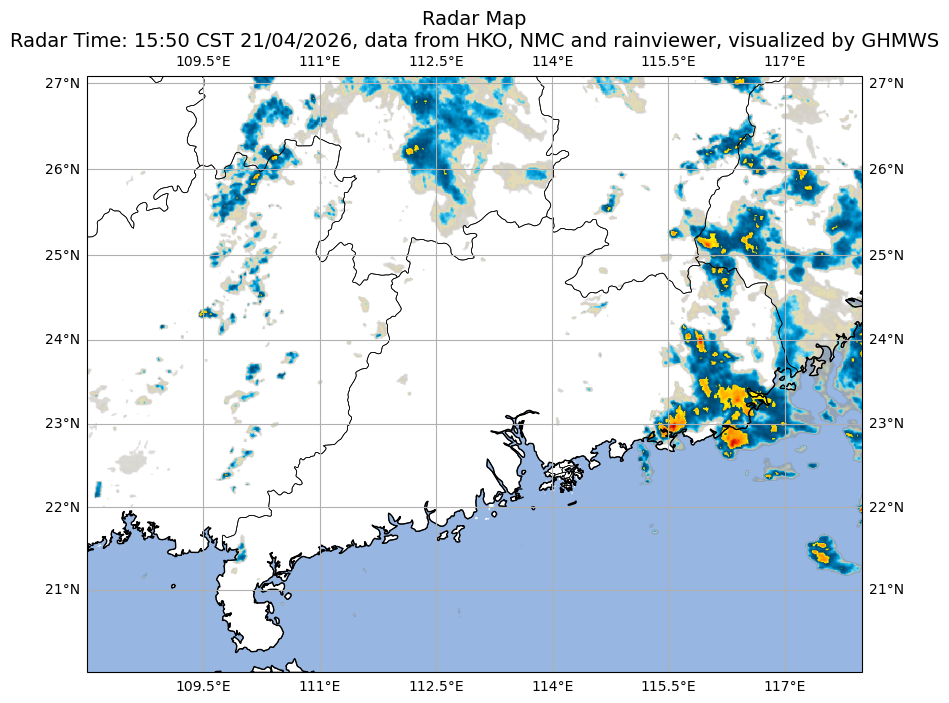

In [9]:
image = np.array(Image.open(urlopen(url)))

import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans']

fig = plt.figure(figsize=(10,10))
proj = ccrs.Mercator(min_latitude=20, max_latitude=28)
ax = plt.axes(projection=proj)
ax.set_extent([108, 118, 20, 27])

ax.imshow(image, extent=[lon-5.625, lon+5.625, lat-5.625, lat+5.625], transform=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES.with_scale('10m'), linewidths=0.5, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=1, edgecolor='black')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1, edgecolor='black')
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='white', edgecolor='white')
ax.add_feature(cfeature.OCEAN.with_scale('10m'))

title_text = (
    "Radar Map\n"
    f"Radar Time: {dt_object_cst.strftime('%H:%M CST %d/%m/%Y')}, "
    "data from HKO, NMC and rainviewer, visualized by GHMWS"
)
ax.set_title(title_text, size=14, color='k')

gl = ax.gridlines(draw_labels=True)
gl.xlabels_bottom = True
gl.ylabels_left = True

plt.show()